# Recepción y demodulación de una señal AIS (GMSK, loopback Red Pitaya)

Genera una trama AIS de prueba, la transmite en una única ráfaga (no en loop continuo), y demuestra que el receptor la recibe y decodifica correctamente (CRC validado, contenido coincide con lo transmitido).

In [21]:
# ============================================================
# Imports y parametros
# ============================================================
import sys, time, struct, socket
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

import gmsk_tx_signal as txlib
import redpitaya_io as rpio
from gmsk_ais_framing import buscar_tramas

FS      = 125e6
f_lo    = 10.7e6
OFFSET  = 300
BAUD    = 9600.0
BT      = 0.4
L_PULSO = 4

AMPLITUD = 4000
TX_BURST_SAMPLES = 32

SPS_TX = round(FS / BAUD)

HOST = '192.168.1.100'
PORT = 1003          # comandos (config, TX, lectura puntual)
PORT_STREAM = 1004   # streaming -- el servidor empuja cada rafaga solo


In [22]:
# ============================================================
# Generar la trama de prueba
# ============================================================
rng = np.random.RandomState(2024)
words_tx, fc_adj, N_buf, bb_ranura, bits_trama, payload_tx = \
    txlib.generar_senal_ais_prueba(rng, FS, f_lo, OFFSET, SPS_TX, L_PULSO, BT,
                                    AMPLITUD, TX_BURST_SAMPLES)
N_RANURA_REAL = len(bits_trama)

print(f"Ranura de prueba: {N_RANURA_REAL} bits (con stuffing)")
print(f"FCS transmitido: 0x{txlib.crc16_ccitt(payload_tx):04X}")


Ranura de prueba: 228 bits (con stuffing)
FCS transmitido: 0xEB4D


In [23]:
# ============================================================
# Conectar con la Red Pitaya
# ============================================================
cfg_reset, cfg_run = rpio.calcular_pinc_y_cfg(f_lo, FS)
sock = rpio.abrir_y_arrancar(HOST, PORT, words_tx, cfg_reset, cfg_run)
rpio.tx_stop(sock)
time.sleep(0.05)   # margen para que el squelch vea silencio real y sembre bien
print(f"Conectado a {HOST}:{PORT}")


Conectado a 192.168.1.100:1003


In [24]:
# ============================================================
# Helpers de lectura/analisis y elegir_punto_prueba ahora viven en
# redpitaya_io.py
# ============================================================
from redpitaya_io import PUNTO_SALIDA_NORMAL, PUNTO_FIR, PUNTO_ROTADOR, PUNTO_SOFT, PUNTO_BIT_CRUDO


In [25]:
# ============================================================
# Transmitir UNA sola rafaga (no un loop continuo) y leer lo demodulado
# -- usa rpio.transmitir_y_recibir(), que hace todo el flujo (parar,
# cargar, arrancar, esperar con margen, leer, parar de nuevo)
# ============================================================
rpio.elegir_punto_prueba(sock, PUNTO_SALIDA_NORMAL)
bits_recibidos = rpio.transmitir_y_recibir(sock, words_tx, FS)
print(f"Bits leidos: {len(bits_recibidos)}")


Punto de prueba -> salida normal
Bits leidos: 1024


In [26]:
# ============================================================
# Validar: se encontro la trama, con CRC correcto, y coincide con lo
# transmitido?
# ============================================================
tramas = buscar_tramas(bits_recibidos)

print(f"Tramas validadas por CRC: {len(tramas)}")
for datos in tramas:
    coincide = np.array_equal(datos, np.array(payload_tx, dtype=np.uint8))
    print(f"  -> coincide EXACTO con lo transmitido: {coincide}")

if not tramas:
    print("Ninguna trama encontrada -- revisar timing de la lectura o nivel de señal.")


Tramas validadas por CRC: 1
  -> coincide EXACTO con lo transmitido: True


In [27]:
# ============================================================
# Limpieza: detener TX y cerrar el socket
# ============================================================
rpio.tx_stop(sock)
sock.close()


## Barrido de SNR: demostración con señal cada vez más ruidosa


In [28]:
# ============================================================
# Conexion de comandos propia para esta seccion
# ============================================================
sock_cmd_stream = rpio.conectar_comandos(HOST, PORT)
rpio.elegir_punto_prueba(sock_cmd_stream, PUNTO_SALIDA_NORMAL)
print(f"Conectado a {HOST}:{PORT} para el barrido de SNR")


Punto de prueba -> salida normal
Conectado a 192.168.1.100:1003 para el barrido de SNR


In [29]:
# ============================================================
# Barrido de SNR
# ============================================================
def barrido_snr(sock, snr_db_lista, n_intentos_por_snr=5, semilla=2024):
    resultados = {}
    for snr_db in snr_db_lista:
        exitos = 0
        for intento in range(n_intentos_por_snr):
            rng = np.random.RandomState(semilla)  # misma trama en cada intento, para comparar parejo
            words_tx_i, fc_adj_i, N_buf_i, bb_i, bits_trama_i, payload_tx_i = \
                txlib.generar_senal_ais_prueba(rng, FS, f_lo, OFFSET, SPS_TX, L_PULSO, BT,
                                                AMPLITUD, TX_BURST_SAMPLES)
            words_ruidosas = txlib.agregar_ruido(words_tx_i, snr_db, rng=rng)
            
            snr_real = txlib.medir_snr(words_tx_i, words_ruidosas)
            print(f"SNR pedido: {snr_db} dB — SNR medido: {snr_real:.2f} dB")

            bits = rpio.transmitir_y_recibir(sock, words_ruidosas, FS)
            tramas = buscar_tramas(bits)
            ok = any(np.array_equal(d, np.array(payload_tx_i, dtype=np.uint8)) for d in tramas)
            estado = "OK" if ok else "FALLO"
            print(f"    intento {intento+1}/{n_intentos_por_snr}: [{estado}] ({len(tramas)} trama(s) valida(s) por CRC)")
            if ok:
                exitos += 1

        tasa = exitos / n_intentos_por_snr
        resultados[snr_db] = tasa
        print(f"SNR={snr_db:+5.1f} dB: {exitos}/{n_intentos_por_snr} exitosas ({tasa*100:.0f}%)")
        print()

    return resultados


SNR_DB_LISTA = [70, 60, 50, 40, 30, 20, 10, 5, 0]   # de limpia a degradada
resultados_snr = barrido_snr(sock_cmd_stream, SNR_DB_LISTA, n_intentos_por_snr=5)


SNR pedido: 70 dB — SNR medido: 69.56 dB
    intento 1/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 70 dB — SNR medido: 69.56 dB
    intento 2/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 70 dB — SNR medido: 69.56 dB
    intento 3/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 70 dB — SNR medido: 69.56 dB
    intento 4/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 70 dB — SNR medido: 69.56 dB
    intento 5/5: [OK] (1 trama(s) valida(s) por CRC)
SNR=+70.0 dB: 5/5 exitosas (100%)

SNR pedido: 60 dB — SNR medido: 59.95 dB
    intento 1/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 60 dB — SNR medido: 59.95 dB
    intento 2/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 60 dB — SNR medido: 59.95 dB
    intento 3/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 60 dB — SNR medido: 59.95 dB
    intento 4/5: [OK] (1 trama(s) valida(s) por CRC)
SNR pedido: 60 dB — SNR medido: 59.95 dB
    intento 5/5: [OK] (1 trama(s) valida(s) por CRC)
SNR=+60.0 dB: 5/5 exitosa

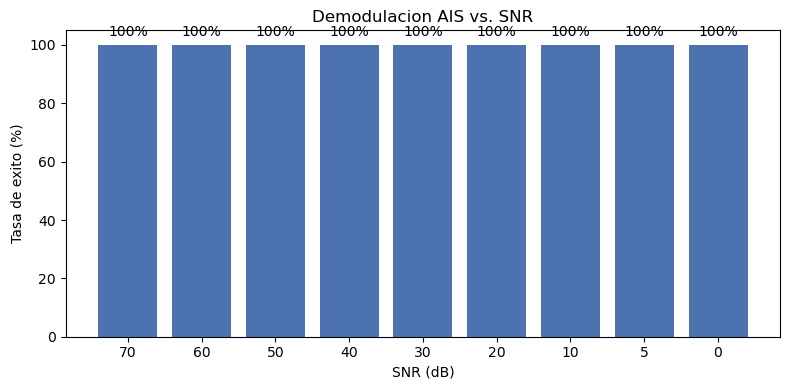

In [30]:
# ============================================================
# Graficar el resultado del barrido
# ============================================================
snr_valores = list(resultados_snr.keys())
tasas = [resultados_snr[s] * 100 for s in snr_valores]

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar([str(s) for s in snr_valores], tasas, color='#4C72B0')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Tasa de exito (%)')
ax.set_title('Demodulacion AIS vs. SNR')
ax.set_ylim(0, 105)
for barra, tasa in zip(barras, tasas):
    ax.text(barra.get_x() + barra.get_width()/2, tasa + 2, f'{tasa:.0f}%',
            ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [31]:
# ============================================================
# Limpieza
# ============================================================
sock_cmd_stream.close()
